In [1]:
import anndata as ad
import squidpy as sq
import cellcharter as cc
import pandas as pd
import scanpy as sc
import scvi
import numpy as np
import matplotlib.pyplot as plt
from lightning.pytorch import seed_everything
from pathlib import Path
from skimage.io import imread
import spatialdata as spd

import torch
torch.set_float32_matmul_precision("high")

seed_everything(1337)
scvi.settings.seed = 1337

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
[rank: 0] Seed set to 1337
[rank: 0] Seed set to 1337


# Preparing data

In [2]:
zarr_file = "/home/janzules/spatial/CAR-T/data/cell2location/adata/zarrFiles/CART_centroid_with_annotations"
zdata = spd.read_zarr(zarr_file)

In [10]:
ST_sample = zdata.tables["segmentation_counts"]

## Adding images

In [5]:
ST_sample.obsm["spatial"] = ST_sample.obs[["cx", "cy"]].to_numpy()

In [12]:
sc.pp.filter_genes(ST_sample, min_counts=3)
sc.pp.filter_cells(ST_sample, min_counts=50)

In [13]:
ST_sample.layers['counts'] = ST_sample.X.copy()

In [14]:
sc.pp.normalize_total(ST_sample, target_sum=1e6)
sc.pp.log1p(ST_sample)

# Testing

In [18]:
ST_sample.obs.head()

,sample,cell_id,region,TMA,mouse,tissue,condition,tumor_loc,replicate_num,_indices,_scvi_batch,_scvi_labels,batch_core,c2l_label_perm,c2l_label_strict,mt_counts,total_RNA_counts,treatment,n_counts
F07839_cellid_000000001-1,F07839,F07839_cellid_000000001-1,CyPSCA_1_1_cell_boundaries,F07839,CyPSCA_1_1,CyPSCA_1_1,CyPSCA,1,1,0,0,0,F07839__CyPSCA_1_1,CAR_T_cell,Unknown,59.0,2440.0,CyPSCA_Tu1,2564.0
F07839_cellid_000000002-1,F07839,F07839_cellid_000000002-1,CyPSCA_1_1_cell_boundaries,F07839,CyPSCA_1_1,CyPSCA_1_1,CyPSCA,1,1,1,0,0,F07839__CyPSCA_1_1,Unknown,Unknown,63.0,1974.0,CyPSCA_Tu1,2098.0
F07839_cellid_000000004-1,F07839,F07839_cellid_000000004-1,CyPSCA_1_1_cell_boundaries,F07839,CyPSCA_1_1,CyPSCA_1_1,CyPSCA,1,1,2,0,0,F07839__CyPSCA_1_1,Erythrocyte,Erythrocyte,12.0,1042.0,CyPSCA_Tu1,1080.0
F07839_cellid_000000005-1,F07839,F07839_cellid_000000005-1,CyPSCA_1_1_cell_boundaries,F07839,CyPSCA_1_1,CyPSCA_1_1,CyPSCA,1,1,3,0,0,F07839__CyPSCA_1_1,Unknown,Unknown,14.0,1643.0,CyPSCA_Tu1,1702.0
F07839_cellid_000000006-1,F07839,F07839_cellid_000000006-1,CyPSCA_1_1_cell_boundaries,F07839,CyPSCA_1_1,CyPSCA_1_1,CyPSCA,1,1,4,0,0,F07839__CyPSCA_1_1,Unknown,Unknown,31.0,1555.0,CyPSCA_Tu1,1634.0


In [17]:
ST_sample.obs['TMA'].unique()

array(['F07839', 'F07840', 'F08542', 'F08543'], dtype=object)

# Dimensionality Reduction

In [19]:
scvi.model.SCVI.setup_anndata(
    ST_sample,
    layer="counts",
    batch_key="mouse" # after changing
)

model = scvi.model.SCVI(ST_sample)

In [20]:
# # LAPTOP
# model.train(early_stopping=True, enable_progress_bar=True, accelerator="mps")

# COMPUTER
model.train(early_stopping=True, enable_progress_bar=True, accelerator="cuda")

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/19 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=19` reached.


In [21]:
ST_sample.obsm['X_scVI'] = model.get_latent_representation(ST_sample).astype(np.float32)

In [23]:
ST_sample.obs["mouse"] = ST_sample.obs["mouse"].astype("category")
sq.gr.spatial_neighbors(ST_sample, library_key='mouse', coord_type='generic', delaunay=True)

# CellCharter's spatial clustering

In [14]:
# grabbing coords for CyPSCA_1_2

# Adjust this column name if needed
subset = ST_sample[ST_sample.obs['mouse'] == 'CyPSCA_1_2']

# Extract (cx, cy) coordinates
coords = subset.obsm['spatial']

# Compute bounding box
xmin = np.min(coords[:, 0])
xmax = np.max(coords[:, 0])
ymin = np.min(coords[:, 1])
ymax = np.max(coords[:, 1])

print(f"xmin: {xmin}, xmax: {xmax}")
print(f"ymin: {ymin}, ymax: {ymax}")


xmin: 3116.4631871012366, xmax: 8908.762357234882
ymin: 3833.2490728455214, ymax: 6528.459009738141


In [15]:
# 1. Subset AnnData for the target mouse/condition
subset = ST_sample[ST_sample.obs['mouse'] == 'CyPSCA_1_2']

# 2. Extract spatial coordinates
coords = subset.obsm['spatial']
xmin, xmax = coords[:, 0].min(), coords[:, 0].max()
ymin, ymax = coords[:, 1].min(), coords[:, 1].max()

# Optional: Add margin (e.g., 100 pixels on each side)
margin = 100
crop_coord = (
    int(xmin - margin),
    int(ymin - margin),
    int(xmax + margin),
    int(ymax + margin)
)

print("Crop coordinates:", crop_coord)


Crop coordinates: (3016, 3733, 9008, 6628)


In [16]:
# Get the unique TMA(s) that contain this mouse
ST_sample.obs.loc[ST_sample.obs['mouse'] == 'CyPSCA_1_2', 'TMA'].unique()

['F07840']
Categories (2, object): ['F07839', 'F07840']

In [29]:
ST_sample.obs['mouse'].unique()

['CyPSCA_1_1', 'CyPSCA_1_2', 'CyPSCA_2_4', 'CyT72_1_4', 'CyT72_2_3', ..., 'RTCyT72_2_4', 'CyT72_1_2', 'NoTx_2_4', 'RTCyPSCA_2_3', 'RTCyT72_1_1']
Length: 16
Categories (16, object): ['CyPSCA_1_1', 'CyPSCA_1_2', 'CyPSCA_2_4', 'CyT72_1_2', ..., 'RTCyPSCA_2_4', 'RTCyT72_1_1', 'RTCyT72_2_1', 'RTCyT72_2_4']

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


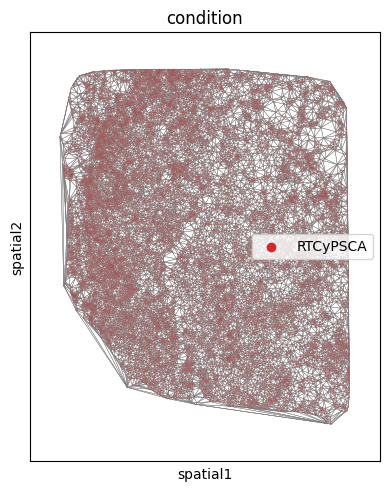

In [31]:
sq.pl.spatial_scatter(
    ST_sample,
    shape=None,
    spatial_key='spatial',
    library_key='mouse',
    library_id=['RTCyPSCA_2_3'],         # or whichever TMA sample contains CyPSCA_1_2
    # crop_coord=crop_coord,
    img=True,
    img_alpha=1,
    color='condition',
    connectivity_key='spatial_connectivities',
    size=0.01,
    edges_width=0.3,
    legend_loc='right',
    # title=['CyPSCA_1_2']
)


In [18]:
cc.gr.remove_long_links(ST_sample)

/home/jon/anaconda3/envs/spatial_analysis_env/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


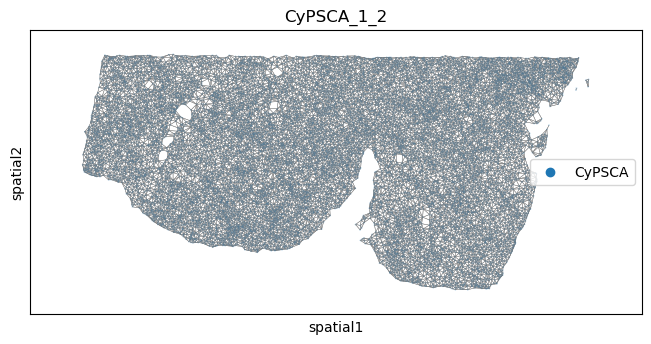

In [19]:
sq.pl.spatial_scatter(
    ST_sample,
    shape=None,
    spatial_key='spatial',
    library_key='mouse',
    library_id=['CyPSCA_1_2'],         # or whichever TMA sample contains CyPSCA_1_2
    crop_coord=crop_coord,
    img=True,
    img_alpha=1,
    color='condition',
    connectivity_key='spatial_connectivities',
    size=0.01,
    edges_width=0.3,
    legend_loc='right',
    title=['CyPSCA_1_2']
)


In [20]:
# output = segmentation_path / "scvi_all.h5ad"

In [21]:
# ST_sample.write(output)

# Clustering

In [22]:
# ST_sample = sc.read_h5ad("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/data/cell_segmentation/concatenated/scvi_all.h5ad")

In [32]:
sq.gr.spatial_neighbors(ST_sample, library_key='mouse', coord_type='generic', delaunay=True, spatial_key='spatial', percentile=99)

In [37]:
cc.gr.aggregate_neighbors(ST_sample, n_layers=[0,1,2], use_rep='X_scVI', out_key='X_cellcharter', sample_key='mouse')

  0%|          | 0/16 [00:00<?, ?it/s]

In [38]:
autok = cc.tl.ClusterAutoK(
    n_clusters=(2,10), 
    max_runs=10,
    convergence_tol=0.001
)

In [39]:
autok.fit(ST_sample, use_rep='X_cellcharter')

Iteration 1/10


  0%|          | 0/11 [00:00<?, ?it/s]

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RAN

Iteration 2/10


  0%|          | 0/11 [00:00<?, ?it/s]

...

  0%|          | 0/11 [00:00<?, ?it/s]

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RAN

Iteration 10/10


  0%|          | 0/11 [00:00<?, ?it/s]

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RAN

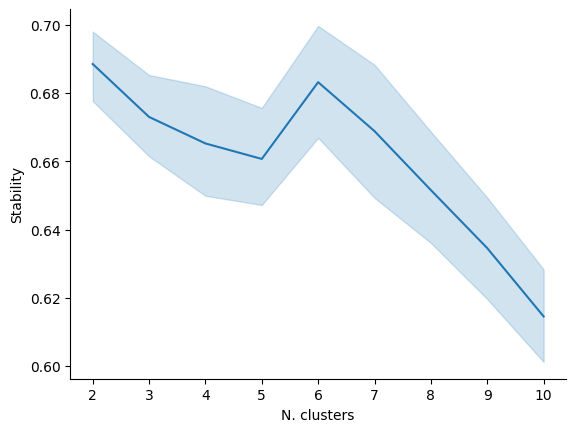

In [40]:
cc.pl.autok_stability(autok)

In [44]:
autok.predict(ST_sample, use_rep='X_cellcharter', k=6)

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


['4', '4', '1', '1', '4', ..., '2', '2', '2', '2', '2']
Length: 425859
Categories (6, object): ['0', '1', '2', '3', '4', '5']

In [45]:
ST_sample.obs['cluster_cellcharter'] = autok.predict(ST_sample, use_rep='X_cellcharter', k=6)

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [47]:
# What did aggregate_neighbors write?
print("X_scVI:", ST_sample.obsm["X_scVI"].shape)
print("X_cellcharter:", ST_sample.obsm["X_cellcharter"].shape)

# If you used n_layers=[0,1,2] and mean only,
# X_cellcharter should be ~ 3x the scVI latent dim.
d = ST_sample.obsm["X_scVI"].shape[1]
print("Expected blocks:", d, d, d)


X_scVI: (425859, 10)
X_cellcharter: (425859, 30)
Expected blocks: 10 10 10


In [46]:
ST_sample.obs.columns

Index(['sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition',
       'tumor_loc', 'replicate_num', '_indices', '_scvi_batch', '_scvi_labels',
       'batch_core', 'c2l_label_perm', 'c2l_label_strict', 'mt_counts',
       'total_RNA_counts', 'treatment', 'n_counts', 'cluster_cellcharter'],
      dtype='object')

In [30]:
ST_sample.obs['mouse'].unique()

['RTCyT72_2_1', 'RTCyPSCA_1_4', 'CyPSCA_1_1', 'NoTx_2_2', 'CyPSCA_1_2', 'RTCyT72_2_4', 'RTCyPSCA_2_4', 'CyT72_1_4']
Categories (8, object): ['CyPSCA_1_1', 'CyPSCA_1_2', 'CyT72_1_4', 'NoTx_2_2', 'RTCyPSCA_1_4', 'RTCyPSCA_2_4', 'RTCyT72_2_1', 'RTCyT72_2_4']

In [38]:
ST_sample.obs.columns

Index(['id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'mouse', 'sample_id', 'condition', 'cx',
       'cy', 'TMA', 'library_id', 'n_counts', '_scvi_batch', '_scvi_labels',
       'cluster_cellcharter'],
      dtype='object')

In [35]:
ST_sample.obs

,id,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,mouse,sample_id,condition,cx,cy,TMA,library_id,n_counts,_scvi_batch,_scvi_labels,cluster_cellcharter
ID_100000,ID_100000,242,5.493061,259.0,5.560682,25.868726,45.173745,83.783784,100.0,RTCyT72_2_1,F07839,RTCyT72,7417.010611,8816.720949,F07839,RTCyT72_2_1,259.0,6,0,2
ID_100001,ID_100001,50,3.931826,54.0,4.007333,100.000000,100.000000,100.000000,100.0,RTCyT72_2_1,F07839,RTCyT72,7412.714680,8396.123239,F07839,RTCyT72_2_1,54.0,6,0,1
ID_100005,ID_100005,242,5.493061,262.0,5.572154,26.717557,45.801527,83.969466,100.0,RTCyT72_2_1,F07839,RTCyT72,7740.638464,8367.398556,F07839,RTCyT72_2_1,262.0,6,0,2
ID_100006,ID_100006,52,3.970292,56.0,4.043051,96.428571,100.000000,100.000000,100.0,RTCyT72_2_1,F07839,RTCyT72,6718.276413,8278.489069,F07839,RTCyT72_2_1,56.0,6,0,1
ID_100007,ID_100007,246,5.509388,262.0,5.572154,25.190840,44.274809,82.442748,100.0,RTCyT72_2_1,F07839,RTCyT72,7698.400583,8576.665870,F07839,RTCyT72_2_1,262.0,6,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ID_246544,ID_246544,92,4.532599,102.0,4.634729,58.823529,100.000000,100.000000,100.0,RTCyT72_2_4,F07840,RTCyT72,10931.629079,13495.813703,F07840,RTCyT72_2_4,102.0,7,0,1
ID_246548,ID_246548,66,4.204693,71.0,4.276666,77.464789,100.000000,100.000000,100.0,RTCyT72_2_4,F07840,RTCyT72,10943.012138,13506.361072,F07840,RTCyT72_2_4,71.0,7,0,1
ID_246563,ID_246563,58,4.077537,66.0,4.204693,87.878788,100.000000,100.000000,100.0,RTCyT72_2_4,F07840,RTCyT72,11412.503735,13483.809188,F07840,RTCyT72_2_4,66.0,7,0,1
ID_246577,ID_246577,109,4.700480,119.0,4.787492,50.420168,92.436975,100.000000,100.0,RTCyT72_2_4,F07840,RTCyT72,11258.901402,13575.772225,F07840,RTCyT72_2_4,119.0,7,0,1


# Saving

In [54]:
cellcharter_path = Path("/home/janzules/spatial/CAR-T/data/cellcharter")
cellcharter_path.mkdir(parents=True, exist_ok=True)
out_h5ad = cellcharter_path / "scvi_cellcharter_k6.h5ad"
ST_sample.write_h5ad(out_h5ad)
print("Wrote:", out_h5ad)

Wrote: /home/janzules/spatial/CAR-T/data/cellcharter/scvi_cellcharter_k6.h5ad


In [50]:
# sq.pl.spatial_scatter(
#     ST_sample, 
#     color=['cluster_cellcharter'], 
#     library_key='library_id',  
#     size=0.5, 
#     img=None,
#     spatial_key='spatial',
#     palette='Set2',
#     figsize=(5,5),
#     ncols=1,
#     library_id=['F07839'],
# )

In [ ]:
# sq.pl.spatial_scatter(
#     ST_sample, 
#     color=['cluster_cellcharter'], 
#     library_key='mouse',  
#     size=0.5, 
#     img=None,
#     spatial_key='spatial',
#     palette='Set2',
#     figsize=(5,5),
#     ncols=1,
#     library_id=['CyPSCA_1_2'],
# )